In [35]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import math
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score)

# Task 1

1. Load the dataset using sklearn.


In [3]:
breast_cancer = load_breast_cancer()

2. Convert into DataFrame and explore structure.

In [4]:
df = pd.DataFrame(breast_cancer.data, columns = breast_cancer.feature_names)

In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
df.shape

(569, 30)

In [7]:
df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [8]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


3. Check missing values and duplicates.

In [9]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

Setting the target variable

In [11]:
df["Diagnosis"] = breast_cancer.target

4. Apply feature scaling using StandardScaler and justify its importance.

Separating features and the target

In [12]:
X = df.drop("Diagnosis", axis = 1)
y = df["Diagnosis"]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns = X.columns)

print(  )

Why feature scaling is important: the features in this Breast Cancer dataset have very different ranges. For instance, the mean area values initially were in the 100s range, while the mean smoothness feature has values close to 0.1. ML algorithms that depend on distances can be biased towards features with larger numerical values.

Standard Scaler helps standardize these features by subtracting its mean and dividing its standard deviation, which resultsin features with a mean of 0 and standard deviation 1. This helps ensure that all features contribute equally to the model and improves training speed and accuracy.

# Task 2

1. Split dataset into training and testing sets (80:20)

2. Repeat with 70:30 and 90:10 splits.

In [14]:
def evaluate_split(test_size): # creating a function to avoid repetitive splits
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = test_size, random_state = 42)

    knn = KNeighborsClassifier(n_neighbors = 5)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

3. Compare performance variations across splits.


In [15]:
splits = {
    "80:20": 0.20,
    "70:30": 0.30,
    "90:10": 0.10
}

for name, size in splits.items():
    accuracy = evaluate_split(size)
    print(f"{name} Split Accuracy: {accuracy:.4f}")

80:20 Split Accuracy: 0.9474
70:30 Split Accuracy: 0.9591
90:10 Split Accuracy: 0.9298


4. Analyze how dataset splitting affects model stability and generalization.

80:20 split - high accuracy, implying it can detect breast cancer cases effectively

70:30 split - highest accuracy, larger test set allows for a more comprehensive evaluation of its performance

90:10 split - lowest accuracy, implying that more training data does not guarantee better measured performance

# Task 3

3.1 Heuristic Method for K Selection

1. Compute initial K using heuristic rule (K =√n);where n = number of training samples

2. Use this value as a baseline K.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42) # sticking with the 80:20 split

In [17]:
# calculating heuristic K

n = len(X_train)

k = int(math.sqrt(n))

print("Training samples:", n)
print("Heuristic K:", k) # baseline K

Training samples: 455
Heuristic K: 21


3.2 Model Training

1. Train KNN classifier using heuristic K value.

In [18]:
knn = KNeighborsClassifier(n_neighbors = k)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


2. Experiment with nearby values of K (K ± 5).

In [19]:
k_values = range(k - 5, k + 6)

accuracies = []

for i in k_values:
    model = KNeighborsClassifier(n_neighbors = i)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    print(f"K = {i}, Accuracy = {accuracy:.4f}")

K = 16, Accuracy = 0.9561
K = 17, Accuracy = 0.9474
K = 18, Accuracy = 0.9561
K = 19, Accuracy = 0.9474
K = 20, Accuracy = 0.9474
K = 21, Accuracy = 0.9474
K = 22, Accuracy = 0.9474
K = 23, Accuracy = 0.9474
K = 24, Accuracy = 0.9474
K = 25, Accuracy = 0.9474
K = 26, Accuracy = 0.9474


3. Plot accuracy vs K values.

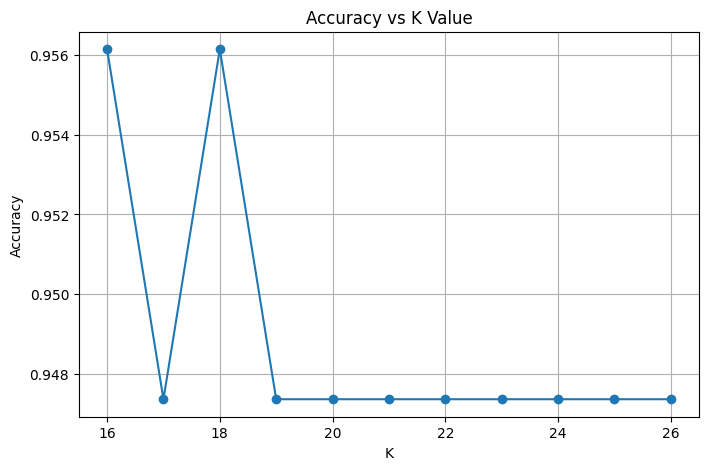

In [20]:
plt.figure(figsize = (8, 5))
plt.plot(k_values, accuracies, marker = "o")
plt.title("Accuracy vs K Value")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

4. Identify optimal K based on performance trend.

In [21]:
best_index = accuracies.index(max(accuracies))

best_k = list(k_values)[best_index]

print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 16
Best Accuracy: 0.956140350877193


3.3 Distance Matrix and Decision Boundary Mapping 


1. Explain any two distance metrics used in KNN: Euclidean Distance and Manhattan Distance. Also mention when each distance metric is suitable.

Euclidean distance - calculates the straight-line distance between two points and is the default distance metric used in KNN. It performs well for continuous numerical data, specifically after feature scaling.

Manhattan Distance - calculates the sum of the absolute differences between feature values. It is less sensitive to outliers and is suitable when movement follows horizontal and vertical paths/when robustness to large deviations is desired.

2. Plot the decision boundary of the KNN classifier for different values of K, such as K = 1, K = 5, K = 10, and K = 20. Analyze how the decision boundary changes as K increase.

In [22]:
pca = PCA(n_components = 2) # reducing data to two principal components

X_pca = pca.fit_transform(X_scaled)

In [23]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size = 0.2, random_state = 42) # splitting the PCA transformed data

In [27]:
def plot_decision_boundary(k):

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_pca, y_train_pca)

    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize = (7, 6))

    plt.contourf(xx, yy, Z, alpha = 0.3, cmap = ListedColormap(("lightcoral", "lightgreen")))

    plt.scatter(X_train_pca[:,0],  X_train_pca[:,1], c = y_train_pca, cmap = ListedColormap(("red", "green")), edgecolor = "k")

    plt.title(f"KNN Decision Boundary (K = {k})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

    plt.show()

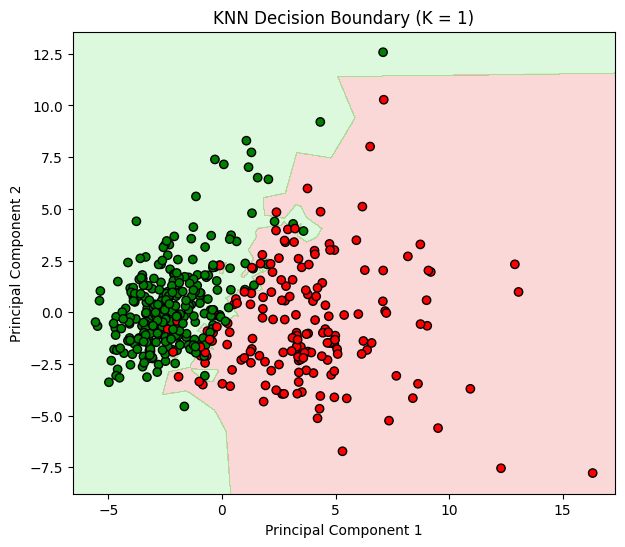

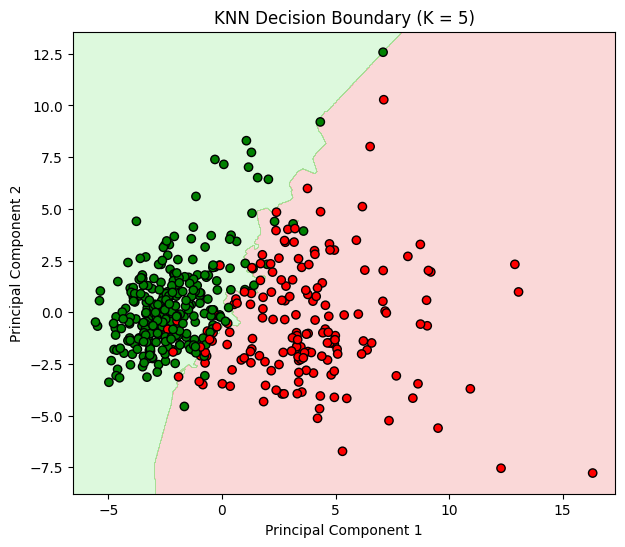

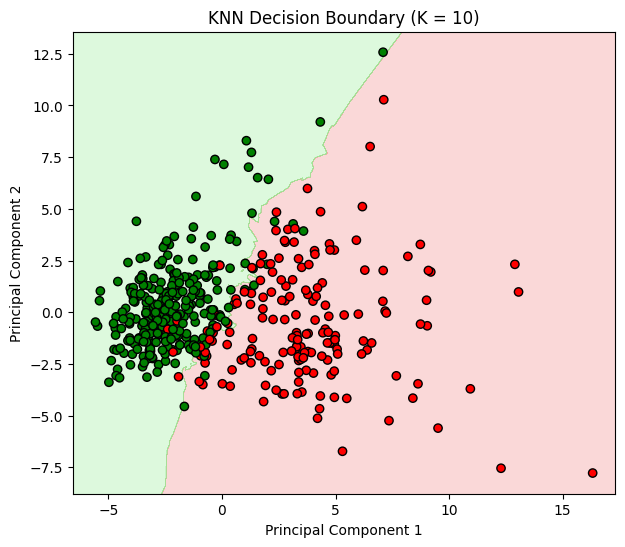

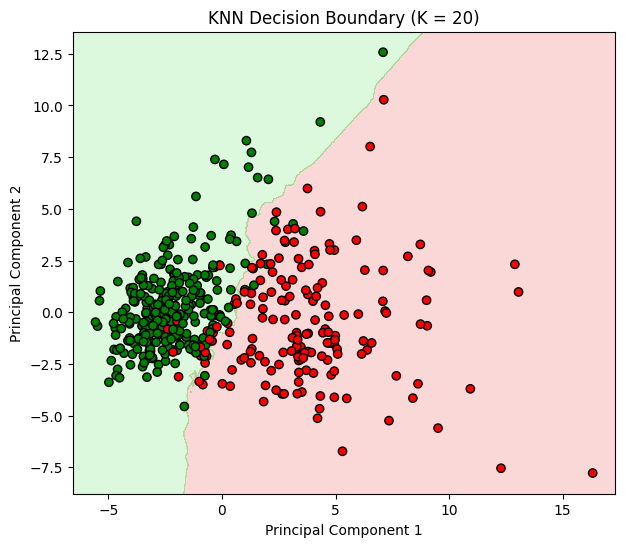

In [28]:
for k in [1, 5, 10, 20]:
    plot_decision_boundary(k)

For K = 1, the decision boundary is the most detailed and contains several small zigzag patterns around the boundary between the two classes. The classifier is highly sensitive to individual training samples, making it more prone to overfitting. It captures local patterns well but it may also classify noise as meaningful information.

For K = 5, the decision boundary becomes smoother than that of K = 1 while still following the overall distribution of the data. The influence of individual samples is reduced, resulting in better generalization. This value provides a good balance between capturing the underlying pattern and avoiding overfitting.

For K = 10, the decision boundary becomes slightly smoother with fewer small irregularities. The classifier relies on a larger neighborhood when making predictions, making it less sensitive to noise. The separation between the two classes remains clear, indicating that the model continues to classify the data effectively.

For K = 20, the decision boundary is the smoothest among all the plots. Local variations are largely eliminated, and the boundary represents the overall trend of the data. While this reduces the risk of overfitting, using a very large K may oversimplify the decision boundary and could lead to underfitting if important local patterns are ignored.

# Task 4

1. Apply K-Fold Cross Validation (k = 5 or 10).

In [30]:
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

2. Compute mean accuracy for different K values.

In [31]:
k_values = range(k - 5, k + 6)

cv_scores = []

for i in k_values:

    model = KNeighborsClassifier(n_neighbors = i)

    scores = cross_val_score(model, X_scaled, y, cv = kf, scoring = "accuracy")

    cv_scores.append(scores.mean())

    print(f"K = {i}, Mean Accuracy = {scores.mean():.4f}")

K = 15, Mean Accuracy = 0.9560
K = 16, Mean Accuracy = 0.9543
K = 17, Mean Accuracy = 0.9543
K = 18, Mean Accuracy = 0.9578
K = 19, Mean Accuracy = 0.9560
K = 20, Mean Accuracy = 0.9560
K = 21, Mean Accuracy = 0.9543
K = 22, Mean Accuracy = 0.9543
K = 23, Mean Accuracy = 0.9543
K = 24, Mean Accuracy = 0.9560
K = 25, Mean Accuracy = 0.9525


3. Compare cross-validation results with train-test split results.


| K Value | Train-Test Accuracy (%) | 5-Fold Cross Validation Mean Accuracy (%) |
|---------:|------------------------:|------------------------------------------:|
| 16 | 95.61 | 95.43 |
| 17 | 94.74 | 95.43 |
| 18 | **95.61** | **95.78** |
| 19 | 94.74 | 95.60 |
| 20 | 94.74 | 95.60 |
| 21 (Heuristic) | 94.74 | 95.43 |
| 22 | 94.74 | 95.43 |
| 23 | 94.74 | 95.43 |
| 24 | 94.74 | 95.60 |
| 25 | 94.74 | 95.25 |

The KNN classifier was evaluated using 5-fold cross-validation for values of K around the heuristic value. Among the tested values, K = 18 achieved the highest mean cross-validation accuracy of 95.78%, indicating the most consistent performance across the five folds.

The train-test split analysis identified K = 16 and K = 18 as the best-performing values, both achieving an accuracy of 95.61%. Cross-validation also identified K = 18 as the best-performing value, with a slightly higher mean accuracy of 95.78%.

4. Select best K based on both heuristic + validation results.

In [33]:
best_index = cv_scores.index(max(cv_scores))

best_k = list(k_values)[best_index]

print("Best K:", best_k)
print("Mean Accuracy:", max(cv_scores))

Best K: 18
Mean Accuracy: 0.9577860580655179


# Task 5

Evaluate final model using:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC Curve and AUC Score


Using the same 80:20 train test split from task 3 ...

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


In [37]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9452054794520548


In [38]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.971830985915493


In [39]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9583333333333334


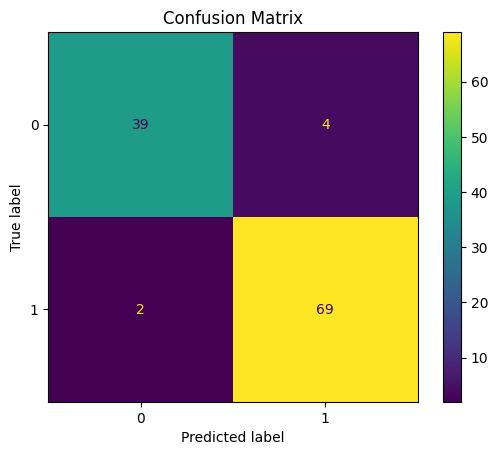

In [41]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [42]:
y_prob = knn.predict_proba(X_test)[:, 1] # we need probabilities instead of predicted labels

In [43]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

AUC Score: 0.9944317065181788


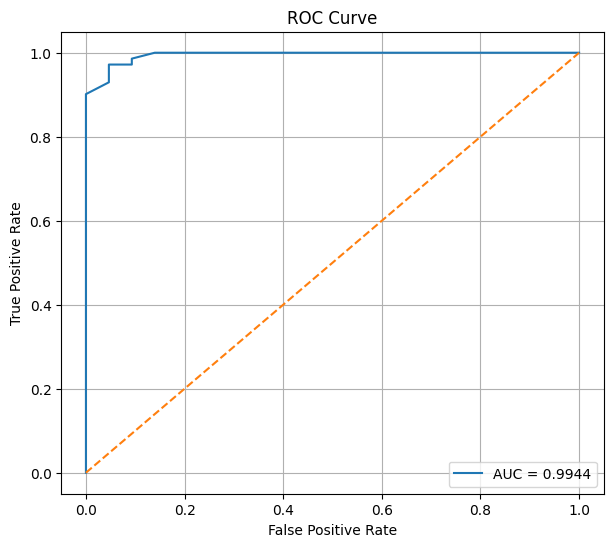

In [44]:
plt.figure(figsize = (7, 6))
plt.plot(fpr, tpr, label = f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle = "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

The ROC curve lies close to the top-left corner of the graph, indicating excellent discrimination between the two classes. 

The AUC score of 0.9944 is very close to 1.0, which signifies outstanding classification performance. This means that the KNN model has an excellent ability to distinguish between malignant and benign breast cancer cases across different classification thresholds.

| Metric | Value |
|---------|------:|
| Accuracy | **94.74%** |
| Precision | **94.52%** |
| Recall | **97.18%** |
| F1 Score | **95.83%** |
| AUC Score | **99.44%** |

The final KNN classifier achieved an accuracy of 94.74%, indicating that it correctly classified most breast cancer cases in the test dataset. 

The precision of 94.52% shows that when the model predicted a sample as benign, it was correct in most cases. 

The recall of 97.18% indicates that the classifier successfully identified the majority of the actual benign cases, missing only a small number of them. 

The F1 score of 95.83% demonstrates a good balance between precision and recall, confirming that the classifier performs consistently across both measures.

| Actual / Predicted | Malignant (0) | Benign (1) |
|-------------------|--------------:|-----------:|
| **Malignant (0)** | 39 | 4 |
| **Benign (1)** | 2 | 69 |

The confusion matrix shows that the classifier correctly identified 39 malignant and 69 benign cases. 

It incorrectly classified 4 malignant cases as benign and 2 benign cases as malignant. 

The number of correct predictions is much higher than the number of misclassifications, demonstrating that the model performs well on both classes.

The relatively small number of errors contributes to the high accuracy and F1 score achieved by the classifier.

# Task 6

1. Compare regression evaluation metrics with classification metrics.

| Regression Evaluation Metrics (Lab 3) | Classification Evaluation Metrics (Lab 5) | Purpose |
|---------------------------------------|-------------------------------------------|---------|
| Mean Absolute Error (MAE) | Accuracy | MAE measures the average prediction error, while Accuracy measures the proportion of correctly classified instances. |
| Mean Squared Error (MSE) | Precision | MSE measures the squared prediction error, whereas Precision measures how many predicted positive instances are actually positive. |
| Root Mean Squared Error (RMSE) | Recall | RMSE measures the magnitude of prediction error, whereas Recall measures the proportion of actual positive instances correctly identified. |
| R² Score | F1 Score | R² Score measures how well the regression model explains the variance in the data, while F1 Score provides a balance between Precision and Recall. |
| – | Confusion Matrix | Used only in classification to summarize correct and incorrect predictions (True Positives, True Negatives, False Positives, and False Negatives). |
| – | ROC Curve & AUC Score | Used only in classification to evaluate the model's ability to distinguish between different classes across various decision thresholds. |

2. Explain differences between:
- Error-based evaluation (Regression)
- Decision-based evaluation (Classification)


Regression models predict continuous numerical values. Their performance is evaluated by measuring the difference (error) between the predicted values and the actual values. Metrics such as MAE, MSE, and RMSE quantify prediction errors, while the R² score measures how well the model explains the variation in the target variable.

Classification models predict discrete class labels rather than numerical values. Their performance is evaluated based on whether each prediction is correct or incorrect. Metrics such as Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC assess the classifier's ability to correctly assign instances to their respective classes.

3. Compare:
- R² Score vs Accuracy
- RMSE vs F1 Score
- MAE vs Confusion Matrix


### R² Score vs Accuracy

| R² Score | Accuracy |
|----------|----------|
| Used to evaluate regression models. | Used to evaluate classification models. |
| Measures how well the regression model explains the variance in the target variable. | Measures the proportion of correctly classified instances. |
| Values typically range from 0 to 1 (or can be negative for poor models), with higher values indicating a better fit. | Values range from 0 to 1, with higher values indicating better classification performance. |
| Suitable for continuous prediction tasks. | Suitable for categorical prediction tasks. |

**Description:**

The R² Score measures how well a regression model fits the data by explaining the variance in the target variable. Accuracy, on the other hand, measures the percentage of correctly classified instances in a classification model. Although both metrics indicate overall model performance, they are designed for different types of machine learning problems.

### RMSE vs F1 Score

| RMSE | F1 Score |
|------|----------|
| Used in regression models. | Used in classification models. |
| Measures the average magnitude of prediction errors. | Measures the balance between Precision and Recall. |
| Lower values indicate better model performance. | Higher values indicate better model performance. |
| Penalizes larger prediction errors more heavily. | Balances the effects of false positives and false negatives. |
| Suitable for continuous numerical predictions. | Suitable for classification tasks, especially when both Precision and Recall are important. |

**Description:**

RMSE evaluates the prediction error of a regression model by measuring how far the predicted values deviate from the actual values. The F1 Score evaluates classification performance by combining Precision and Recall into a single metric, making it useful when both false positives and false negatives need to be considered.

### MAE vs Confusion Matrix

| MAE | Confusion Matrix |
|-----|------------------|
| Used in regression models. | Used in classification models. |
| Measures the average absolute difference between predicted and actual values. | Displays the number of correct and incorrect predictions for each class. |
| Produces a single numerical error value. | Produces a matrix showing True Positives, True Negatives, False Positives, and False Negatives. |
| Lower values indicate better model performance. | Higher numbers of correct classifications indicate better model performance. |
| Suitable for continuous prediction tasks. | Suitable for categorical prediction tasks. |

**Description:**

MAE summarizes the average prediction error of a regression model as a single numerical value. In contrast, the Confusion Matrix provides a detailed breakdown of classification results by showing the number of correctly and incorrectly classified instances, making it easier to understand the types of errors made by the classifier.

4. Discuss differences in evaluation logic for:
- Continuous prediction tasks
- Classification tasks


Regression (Continuous Prediction) is used when the target variable is continuous, such as predicting house prices, sales revenue, temperature, or stock prices. The objective is to minimize the difference between predicted and actual numerical values, making error-based metrics such as MAE, MSE, RMSE, and R² appropriate for evaluation.

Classification is used when the target variable consists of discrete categories, such as benign or malignant cancer diagnosis, spam detection, or sentiment analysis. Since predictions belong to predefined classes, evaluation focuses on the correctness of classification decisions using metrics such as Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC.

# Task 7

1. Why is KNN called a lazy learning algorithm?

K-Nearest Neighbors (KNN) is called a **lazy learning algorithm** because it does not build a predictive model during the training phase. Instead, it simply stores the training data. When a new data point needs to be classified, KNN computes the distance between the new instance and all training samples, identifies the K nearest neighbors, and predicts the class based on the majority vote. Since most of the computation is performed during prediction rather than training, KNN is referred to as a lazy learner.

2. Why is feature scaling required in KNN?

KNN is a **distance-based algorithm** that uses distance measures such as Euclidean or Manhattan distance to identify the nearest neighbors. If features have different numerical ranges, features with larger values will dominate the distance calculation. Feature scaling standardizes all features to a similar scale, ensuring that each feature contributes equally to the distance computation and improving the performance of the KNN classifier.

3. Explain heuristic K selection using √n rule.

The heuristic method estimates an initial value of K using the formula:

**K = √n**

where **n** is the number of training samples.

The calculated value serves as a starting point for selecting K. Nearby values (K ± 5) are then evaluated to identify the optimal K based on model performance. This heuristic provides a reasonable balance between very small and very large values of K.


4. Why is cross-validation more reliable than a single train-test split?

A single train-test split evaluates the model using only one partition of the dataset, making the results dependent on that specific split. In contrast, K-Fold Cross Validation divides the dataset into multiple folds and evaluates the model several times using different training and testing partitions. The final performance is obtained by averaging the results across all folds, providing a more reliable and stable estimate of the model's generalization performance.

5. How does K affect the bias-variance trade-off?

The value of K directly influences the bias-variance trade-off in KNN.

- **Small K values** (e.g., K = 1) produce complex decision boundaries that closely follow the training data. This results in **low bias but high variance**, making the model more prone to overfitting.
- **Large K values** produce smoother decision boundaries by considering more neighbors. This results in **higher bias but lower variance**, making the model more stable but increasing the risk of underfitting.

An appropriate value of K balances bias and variance to achieve good generalization.

6. Why is recall more important than accuracy in cancer prediction?

In cancer prediction, **recall** is often more important than accuracy because it measures the proportion of actual positive cases that are correctly identified. Missing a patient who truly has cancer (a false negative) can delay diagnosis and treatment, leading to serious consequences. Although accuracy provides an overall measure of performance, it does not distinguish between different types of errors. Therefore, achieving a high recall is critical in medical diagnosis to minimize missed cancer cases.

7. What is the limitation of very large K values?

A very large value of K causes the classifier to consider too many neighbors when making predictions. As a result, the model may ignore important local patterns and become biased toward the majority class. This produces overly smooth decision boundaries, increases the likelihood of underfitting, and may reduce the classifier's ability to correctly classify samples that lie near class boundaries.